# Task 2.2 양자 측정 결과 시각화

**개요:** 이 노트북에서는 양자 회로의 측정 결과를 시각화하는 방법을 다룹니다.

Qiskit에서는 측정 결과를 여러 방식으로 시각화할 수 있으며, 결과를 정확하게 표현하려면 목적에 맞는 시각화 방식을 선택하는 것이 중요합니다.


In [29]:
# 설정: 필요한 라이브러리 불러오기
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit,QuantumRegister, ClassicalRegister, transpile
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.quantum_info import Statevector
print("라이브러리를 성공적으로 불러왔습니다.")

라이브러리를 성공적으로 불러왔습니다.


In [ ]:
# 한글폰트가 깨지는 경우 실행 (깨지지 않았을 때에도 실행해도 무방)

import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Malgun Gothic", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

In [31]:
# 필요한 라이브러리 설치 (이미 설치되어 있다면 이 부분은 건너뛰어도 됩니다)
# !pip install pydot
# !pip install seaborn
# !pip install sympy

## 목표 1: 측정 결과 시각화

Qiskit은 양자 측정 결과와 양자 상태를 분석하기 위한 다양한 시각화 도구를 제공합니다.

### 기본 히스토그램 그리기

`plot_histogram`은 양자 측정 결과를 시각화할 때 가장 자주 쓰이는 함수로, 측정 결과의 빈도 분포를 막대그래프로 보여줍니다.

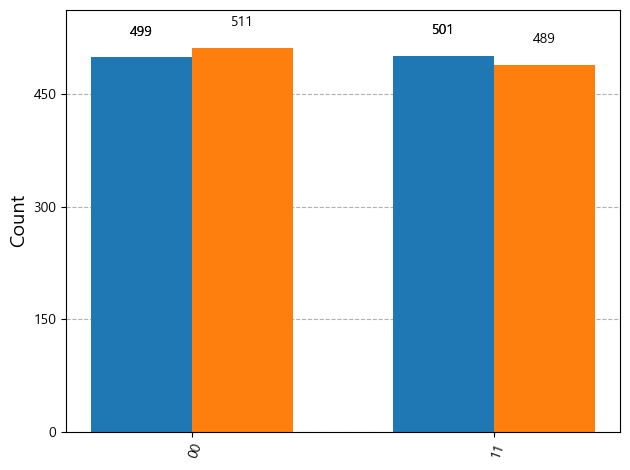

In [32]:
from qiskit.visualization import plot_histogram
# 양자 회로에서 얻은 측정 결과를 가정한 예시
counts1 = {'00': 499, '11': 501}  # 첫 번째 실행: 거의 동일한 분포
counts2 = {'00': 511, '11': 489}  # 두 번째 실행: |00⟩ 쪽으로 약간 치우침

data = [counts1, counts2]
plot_histogram(data)
# 두 번의 서로 다른 회로 실행에서 |00⟩과 |11⟩ 상태가
# 측정될 확률 분포를 보여줍니다.


### 히스토그램 스타일 지정

히스토그램에서 자주 사용하는 인자는 다음과 같습니다.
- `title`: 차트 제목
- `figsize`: 그림 크기 (가로, 세로) [인치]
- `legend`: 여러 데이터 시리즈에 대한 레이블
- `color`: 각 데이터 시리즈의 사용자 지정 색상
- `filename(str)`: 이미지를 저장할 파일 경로

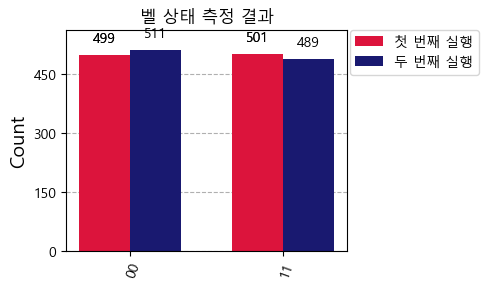

In [33]:
legend = ['첫 번째 실행', '두 번째 실행']
title = '벨 상태 측정 결과'
figsize = (5, 3)
color = ['crimson', 'midnightblue']

plot_histogram(data, 
               legend=legend, 
               title=title, 
               figsize=figsize, 
               color=color)
# 이러한 사용자 지정을 통해 발표 자료나 문서에서 더 정보성 있는 그림을 만들 수 있습니다.

### 양자 시각화의 종류

#### 기본 카운트 시각화

- `plot_histogram`: 측정 결과 빈도를 보여주는 막대그래프

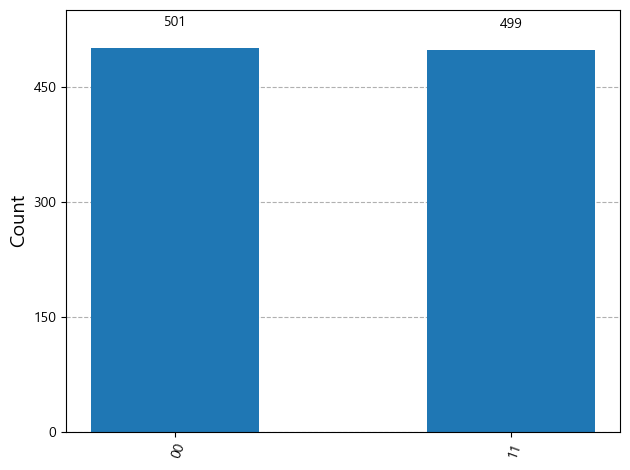

In [34]:
# 이상적인 벨 상태 측정 결과
counts = {"00": 501, "11": 499}
plot_histogram(counts)

# 이는 (|00⟩ + |11⟩)/√2 형태의 거의 완벽한 벨 상태 측정을 나타내며,
# |00⟩과 |11⟩ 결과가 거의 같은 확률로 나옵니다.


- `plot_distribution`: 확률 분포 시각화 (`plot_histogram`에서 모수로 나눈 결과)

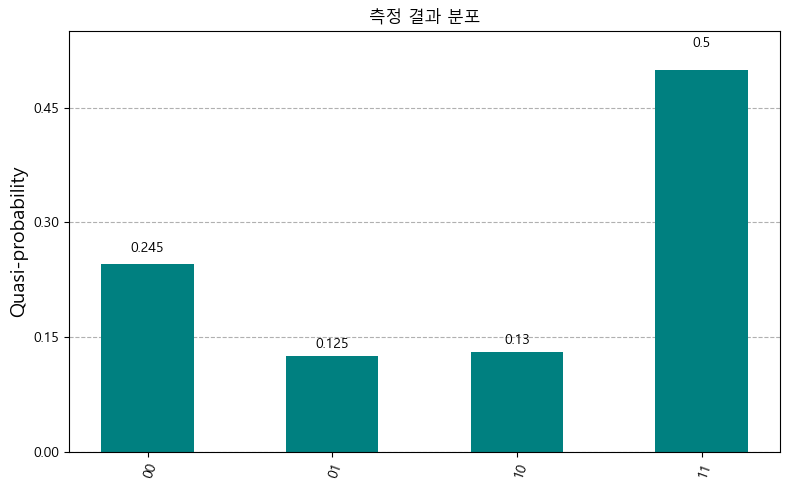

In [35]:
from qiskit.visualization import plot_distribution

counts_data = {
    '00': 245,
    '01': 125,
    '10': 130,
    '11': 500
}

plot_distribution(counts_data, 
                  title="측정 결과 분포",
                  figsize=(8, 5),
                  color='teal',
                  sort='asc')


여러 분포를 한 번에 그려서 비교할 수도 있습니다.

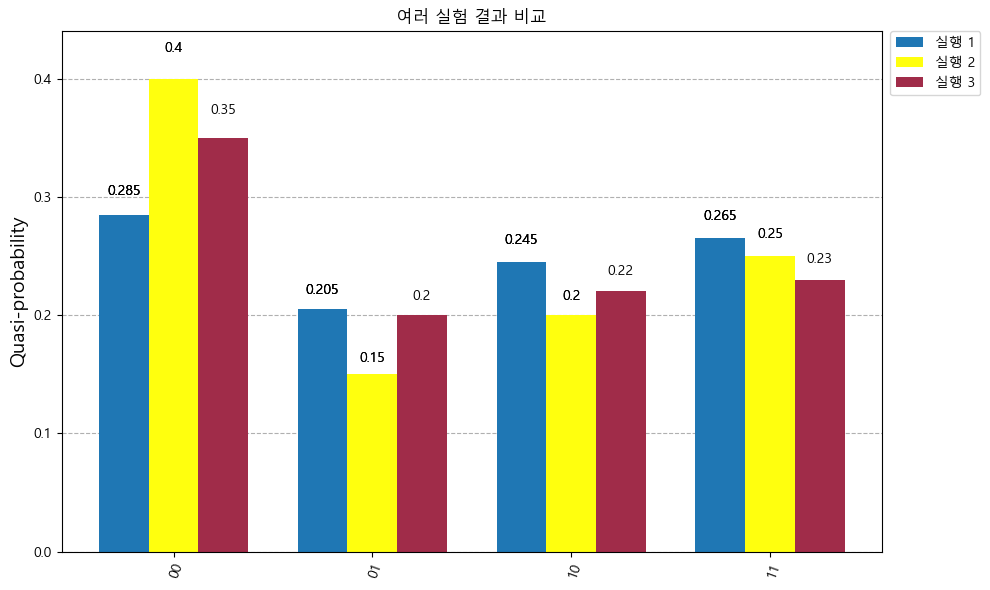

In [36]:
# 비교를 위한 여러 분포
counts_comparison = [
    {'00': 285, '01': 205, '10': 245, '11': 265},  # 첫 번째 실험
    {'00': 400, '01': 150, '10': 200, '11': 250},  # 두 번째 실험
    {'00': 350, '01': 200, '10': 220, '11': 230}   # 세 번째 실험
]

plot_distribution(counts_comparison,
                  title="여러 실험 결과 비교",
                  legend=['실행 1', '실행 2', '실행 3'],
                  figsize=(10, 6),
                  color=['#1f77b4', '#ffff0e', "#a02c49"],
                  bar_labels=True)


#### 양자 상태 시각화

- `plot_bloch_vector`: 단일 큐비트 상태를 블로흐 구 위에 표시

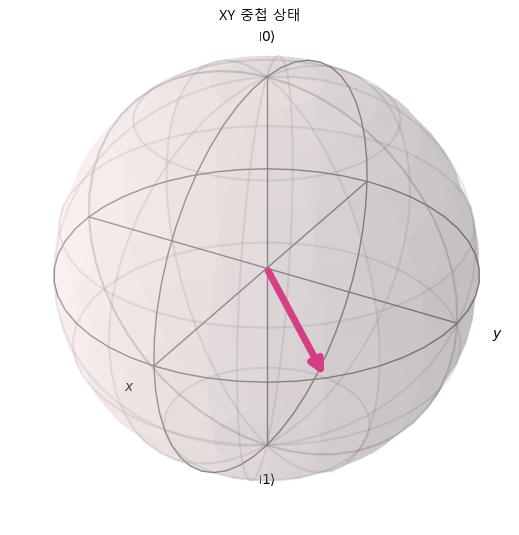

In [37]:
from qiskit.visualization import plot_bloch_vector

# 블로흐 구 위의 다양한 단일 큐비트 상태 예시
bloch_vectors = [1/np.sqrt(2), 1/np.sqrt(2),0]
title = "XY 중첩 상태"


plot_bloch_vector(bloch_vectors, 
                  title=title, 
                  coord_type='cartesian')  # 'spherical'도 사용할 수 있습니다.


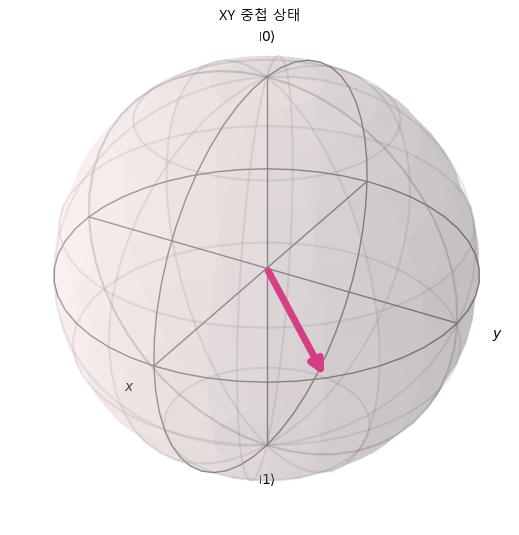

In [38]:
bloch_vectors_spherical = [1, np.pi/2, np.pi/4]  # (r, θ, φ) 형태의 구면 좌표
plot_bloch_vector(bloch_vectors_spherical, 
                  title=title, 
                  coord_type='spherical')

- `plot_bloch_multivector`: 여러 큐비트를 각각의 블로흐 구에 표시
$$
|q_0,q_1,q_2\rangle = \mathrm{i}|1, +, 1\rangle
$$

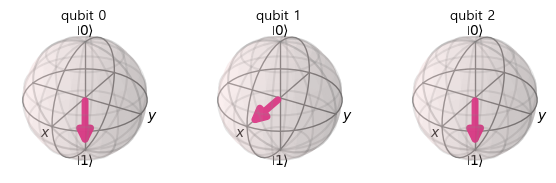

In [39]:
from qiskit.visualization import plot_bloch_multivector

qc = QuantumCircuit(3)
qc.x(0)
qc.h(1)
qc.y(2)
state = Statevector(qc)

plot_bloch_multivector(state,figsize=[2,2])

얽힘상태에 있는 상태에서는 특정 큐비트에서의 파울리 연산자의 기댓값에 의해 표시됩니다.
다음과 같이
$$ |\psi\rangle=\frac{\mathrm{i}}{\sqrt{2}}|1\rangle \otimes (|01\rangle + |10\rangle) $$
일 때, 큐비트 1과 2에 대한 파울리 기댓값 $\langle X\rangle $, $\langle Y\rangle $ 그리고 $\langle Z\rangle$ 모두 0이기 때문에, 벡터가 원점에 위치합니다.

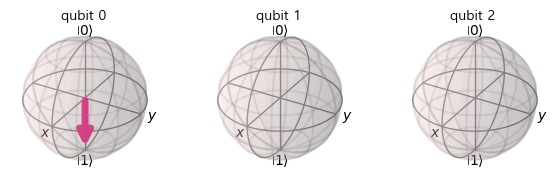

In [40]:
from qiskit.circuit.library import CXGate
qc_entangled = qc.compose(CXGate(), [1, 2], inplace=False)
state_entangled = Statevector(qc_entangled)

plot_bloch_multivector(state_entangled, figsize=[2,2])

- `plot_state_city`: 상태벡터 진폭을 3차원 city plot으로 시각화

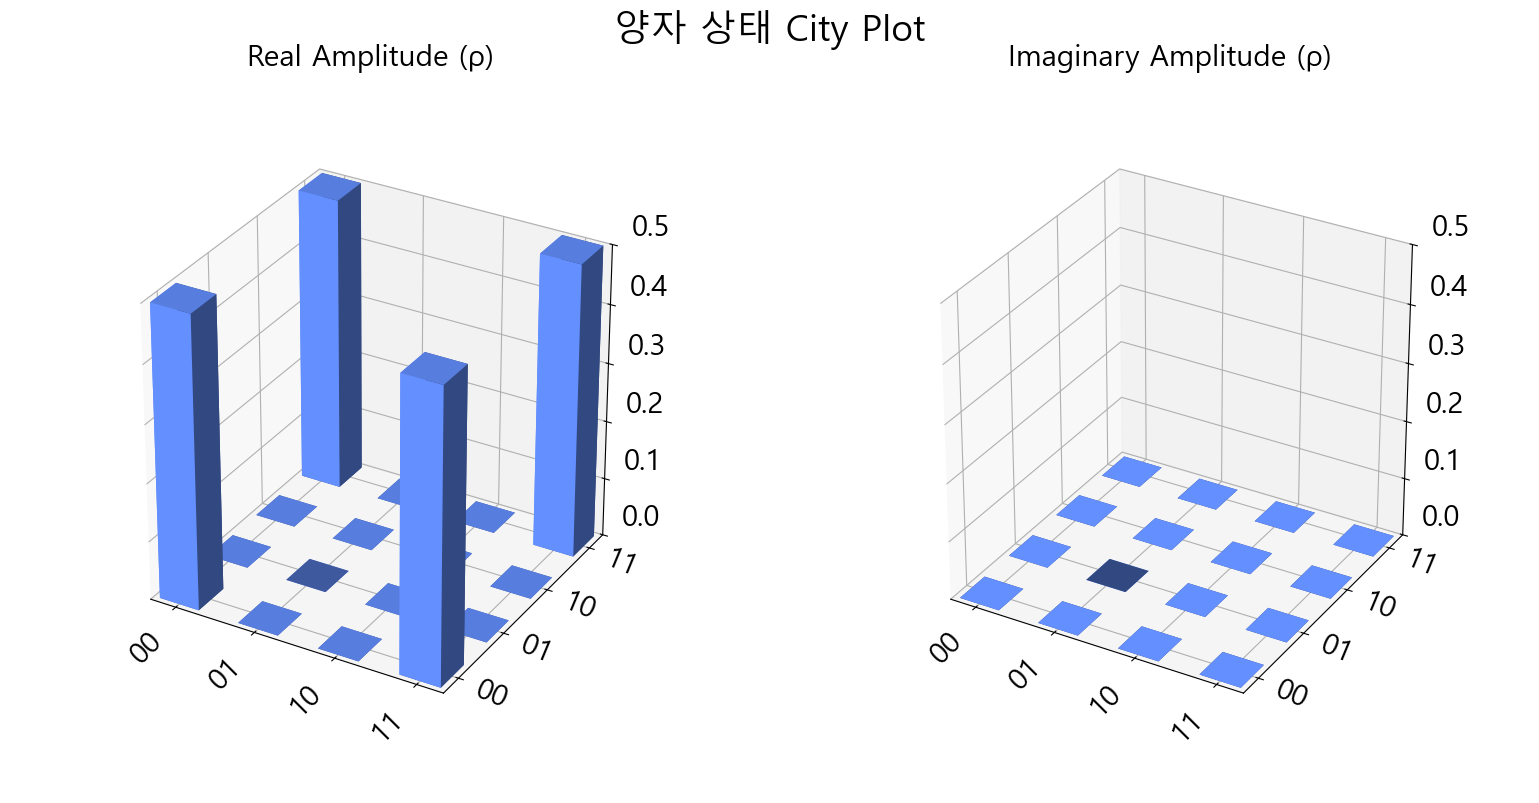

In [41]:
from qiskit.visualization import plot_state_city

qc_bell = QuantumCircuit(2)
qc_bell.h(0)
qc_bell.cx(0, 1)
state_bell = Statevector(qc_bell)

plot_state_city(state_bell, title="양자 상태 City Plot")

# City plot은 상태벡터 또는 밀도행렬 원소의 크기를 보여줍니다.


- `plot_state_hinton`: 밀도행렬 시각화를 위한 힌턴 다이어그램 (각 값의 크기는 도형의 크기로, 부호는 색으로 표현)

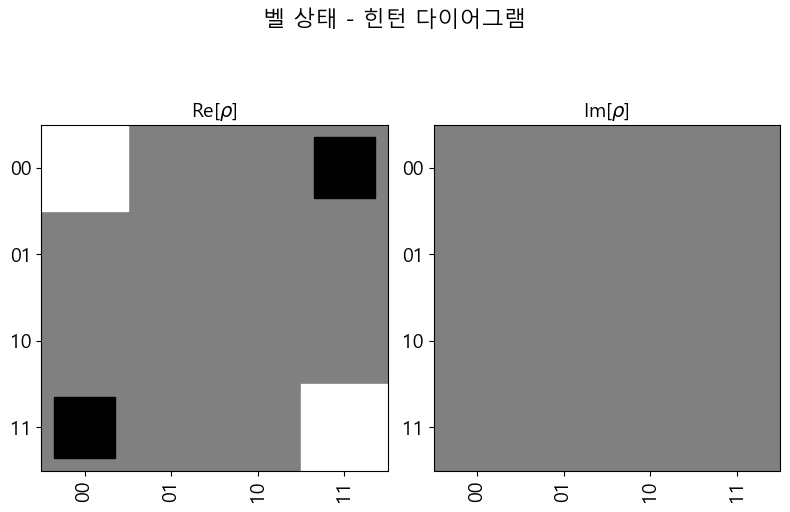

In [42]:
from qiskit.visualization import plot_state_hinton
from qiskit.quantum_info import DensityMatrix

rho = DensityMatrix([[0.5, 0, 0, -0.25],
                     [0, 0, 0, 0],
                     [0, 0, 0, 0],
                     [-0.25, 0, 0, 0.5]])
plot_state_hinton(rho, 
                 title="벨 상태 - 힌턴 다이어그램",
                 figsize=(8, 6))


- `plot_state_paulivec`: 파울리 기대값 시각화 ($\mathrm{Tr}[\rho\sigma],\quad \sigma \in \{X,Y,Z,I\}^{\otimes n}$), 기댓값이 0인 파울리 연산자는 생략


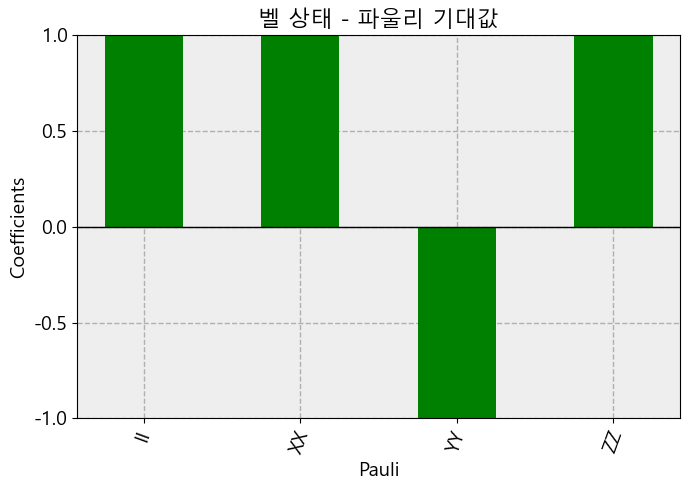

In [43]:
from qiskit.visualization import plot_state_paulivec

plot_state_paulivec(state_bell,
                   title="벨 상태 - 파울리 기대값",
                   figsize=(7, 5),
                   color='green')


- `plot_state_qsphere`: 양자 상태의 Q-sphere 표현

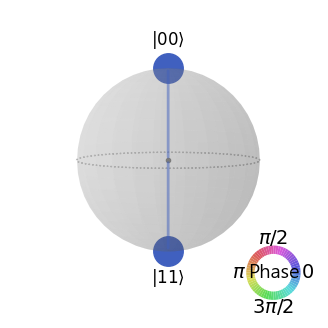

In [44]:
from qiskit.visualization import plot_state_qsphere

plot_state_qsphere(state_bell,figsize=(4,4))

### 기타 시각화 범주

**디바이스 시각화:**

- `plot_gate_map`: 물리 큐비트의 연결 구조와 배치


- `plot_error_map`: 디바이스 전반의 양자 오류율 (여기서 H error rate는 각 큐비트에 대한 단일연산자 오류의 최댓값을 표현)

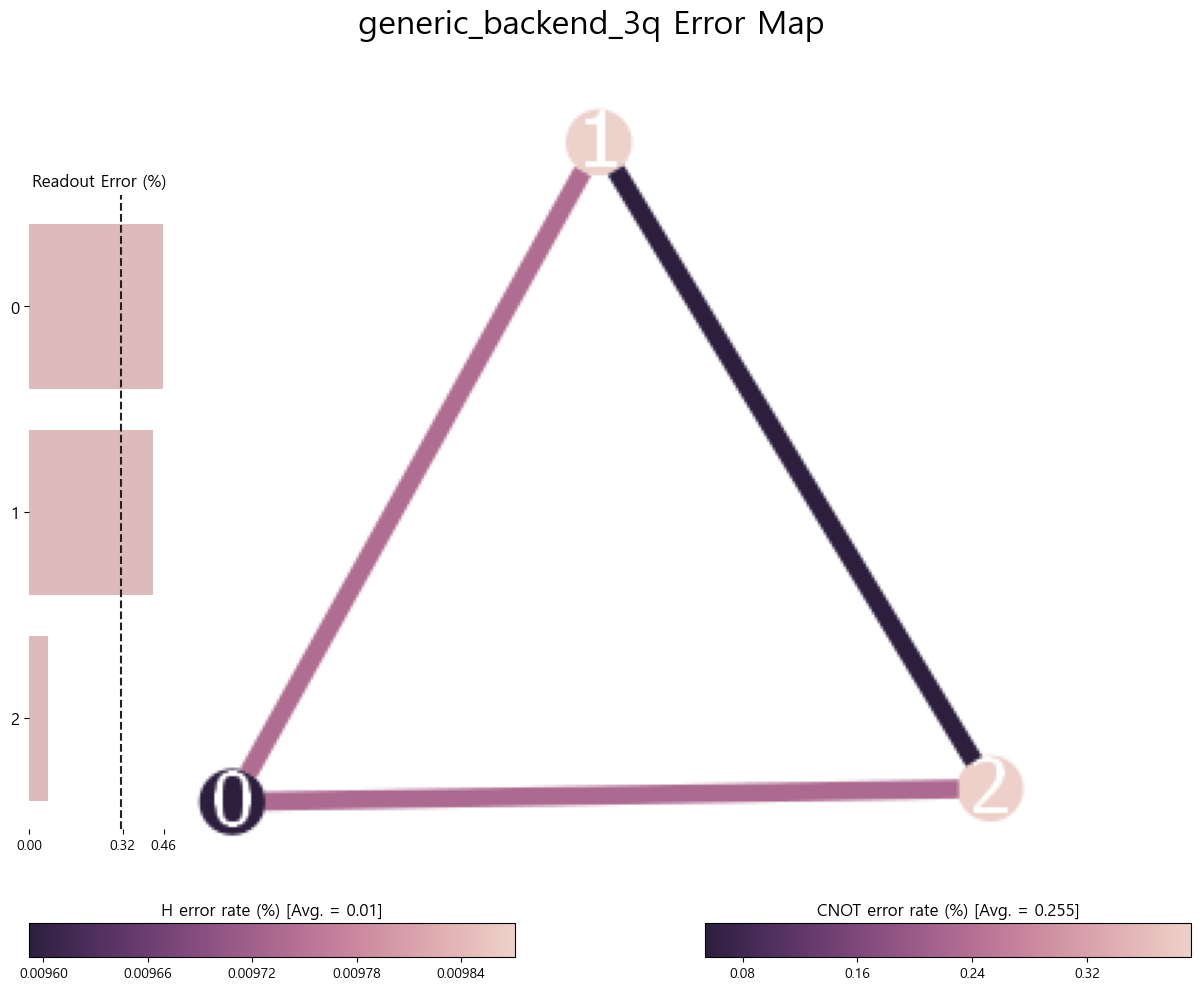

In [45]:
from qiskit.visualization import plot_error_map
 
backend = GenericBackendV2(num_qubits=3)
plot_error_map(backend)


- `plot_circuit_layout`: 회로가 실제 하드웨어에 어떻게 매핑되는지 표시

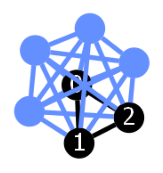

In [46]:
from qiskit.visualization import plot_circuit_layout
 
qc_ghz = QuantumCircuit(3, 3)
qc_ghz.h(0)
qc_ghz.cx(0,1)
qc_ghz.cx(0,2)
qc_ghz.measure_all()
 
backend = GenericBackendV2(num_qubits=7)
qc_ghz_optimized = transpile(qc_ghz, backend=backend, optimization_level=3)
plot_circuit_layout(qc_ghz_optimized, backend)

- `plot_coupling_map`: 큐비트 연결 그래프

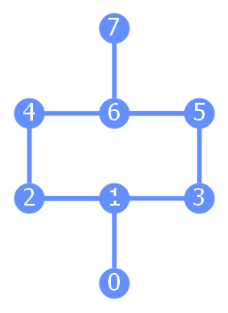

In [47]:
from qiskit.visualization import plot_coupling_map
 
num_qubits = 8
qubit_coordinates = [[0, 1], [1, 1], [1, 0], [1, 2], [2, 0], [2, 2], [2, 1], [3, 1]] # 각 큐비트의 (x, y) 좌표
coupling_map = [[0, 1], [1, 2], [2, 3], [3, 5], [4, 5], [5, 6], [2, 4], [6, 7]] # 큐비트 간의 연결 정보
plot_coupling_map(num_qubits, qubit_coordinates, coupling_map)


**회로 시각화:**

- `circuit_drawer`: 양자 회로 다이어그램

circuit_drawer 함수를 직접 사용합니다:


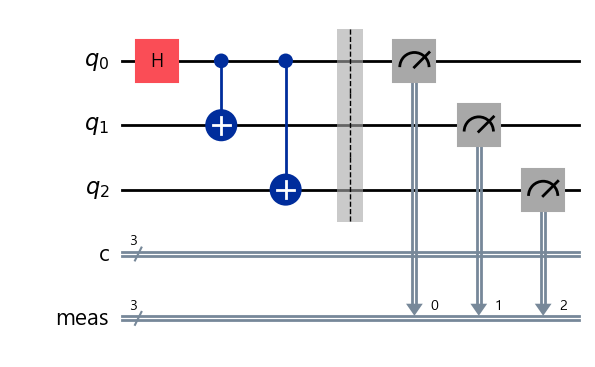

In [48]:
from qiskit.visualization import circuit_drawer

# 회로를 그리는 함수형 인터페이스 사용
print("circuit_drawer 함수를 직접 사용합니다:")
circuit_drawer(qc_ghz, output="mpl")



**DAG 시각화:**
- `dag_drawer`: 방향성 비순환 그래프(Directed Acyclic Graph, DAG) 표현

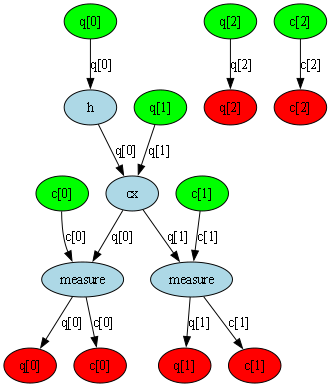

In [49]:
from qiskit.converters import circuit_to_dag
from qiskit.visualization import dag_drawer
 
qc = QuantumCircuit(3,3)
qc.h(0)
qc.cx(0, 1)
qc.measure(0, 0)
qc.measure(1, 1)
 
dag = circuit_to_dag(qc)
 
 
dag_drawer(dag)

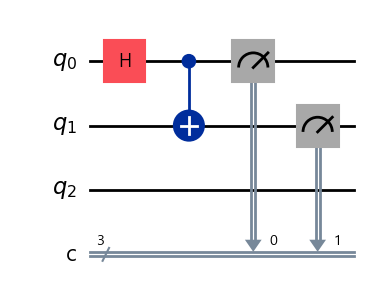

In [50]:
qc.draw(output="mpl") # 비교를 위해 회로의 기본 드로잉 메서드도 사용


**패스 매니저 시각화:**
- `pass_manager_drawer`: 컴파일 패스의 순서를 표시

In [51]:
from qiskit import generate_preset_pass_manager
from qiskit.visualization import pass_manager_drawer

pass_manager = generate_preset_pass_manager(backend=backend, optimization_level=3)
# pass_manager_drawer(pass_manager) # Bug in Windows (Permission Error)

**타임라인 시각화:**
- `timeline_drawer`: 양자 연산 스케줄링 시각화

sx_0 Duration:   184
cx_01 Duration:  2203


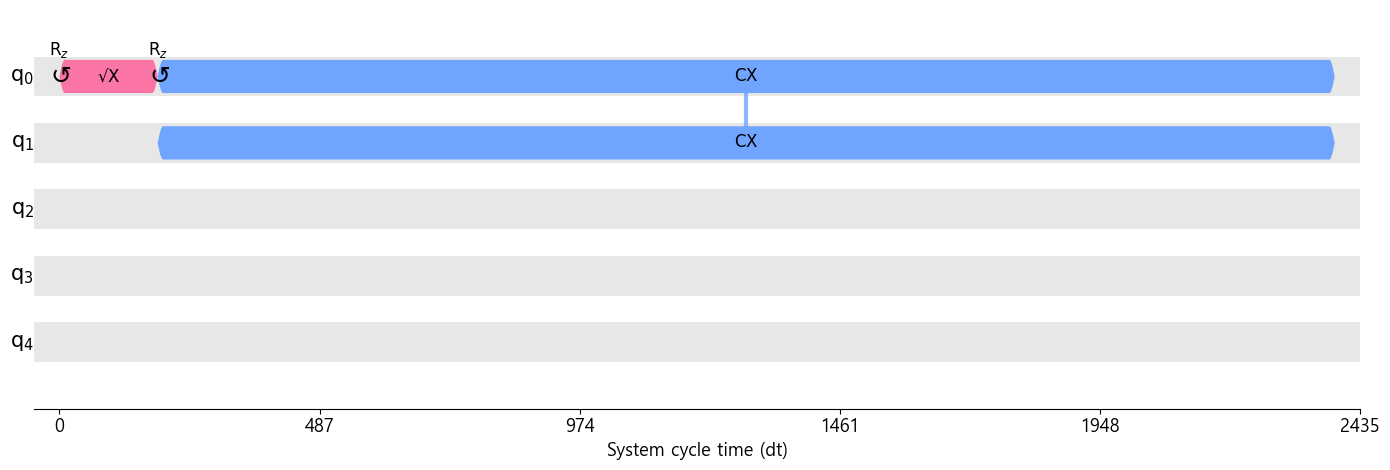

In [52]:
from qiskit.visualization.timeline import draw
 
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)
 
backend = GenericBackendV2(5)
qc = transpile(qc, backend, layout_method='trivial')

print("sx_0 Duration:  ", backend.instruction_durations.get('sx', [0]))
print("cx_01 Duration: ", backend.instruction_durations.get('cx', [0,1]))
draw(qc, target=backend.target)


**단일 큐비트 상태 전이:**
~~- `visualize_transition`: 블로흐 구 위 상태 전이를 애니메이션으로 표시~~ : Deprecated in `1.2`, removed in `2.0`

**배열/행렬 시각화:**
- `array_to_latex`: 배열을 LaTeX 형식으로 변환

In [53]:
from qiskit.visualization import array_to_latex

rho = np.array(rho)
with np.printoptions(precision=2, suppress=True):
    print("밀도 행렬 원소:")
    print(rho)

array_to_latex(rho, prefix=r"\rho = ")

밀도 행렬 원소:
[[ 0.5 +0.j  0.  +0.j  0.  +0.j -0.25+0.j]
 [ 0.  +0.j  0.  +0.j  0.  +0.j  0.  +0.j]
 [ 0.  +0.j  0.  +0.j  0.  +0.j  0.  +0.j]
 [-0.25+0.j  0.  +0.j  0.  +0.j  0.5 +0.j]]


<IPython.core.display.Latex object>

## 목표 3: 게이트 맵 시각화

게이트 맵 시각화는 양자 프로세서의 물리적 배치와 연결 구조를 보여줍니다.


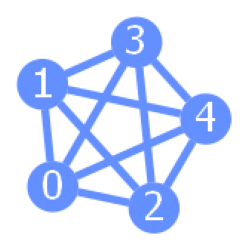

In [54]:
from qiskit.visualization import plot_gate_map

# 5개의 큐비트를 가진 시뮬레이션 백엔드 생성
backend = GenericBackendV2(num_qubits=5)

# 게이트 맵(큐비트 연결 구조) 시각화
plot_gate_map(backend, figsize=[3, 3])


---
## 요약
---

이 노트북에서는 다음 내용을 다뤘습니다.

## 양자 측정 시각화:

1. **결과 시각화 방식**: 히스토그램, 분포
2. **상태 시각화 방식**: 블로흐 벡터, 다중 블로흐 벡터, state city, state hinton, state pauli vector, qsphere
3. **기타 시각화 도구**: 게이트 맵, 오류 맵, 회로 레이아웃, 커플링 맵, DAG, 타임라인


---

## 연습 문제

**1) 모든 계산 기저 상태에 대한 statevector를 블로흐 구와 유사한 형태로 시각화할 때 가장 적절한 Qiskit 함수는 무엇인가요?**

A) plot_bloch_vector()

B) plot_histogram()

C) plot_state_qsphere()

D) plot_state_city()


***정답:***
<Details>
<br/>
C) `plot_state_qsphere`는 다중 큐비트 상태의 전체 구조를 시각화하는 데 사용됩니다.
</Details>


---

**2) 다음 코드를 실행했을 때의 출력으로 가장 적절한 그림은 무엇인가요?**

```
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector

qc = QuantumCircuit(2)
qc.h(0)
qc.x(1)

state = Statevector(qc)
plot_bloch_multivector(state)
```


A) Qubit 0: ●──H──

   Qubit 1: ●──X──

B) 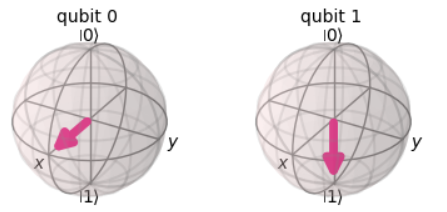

C) 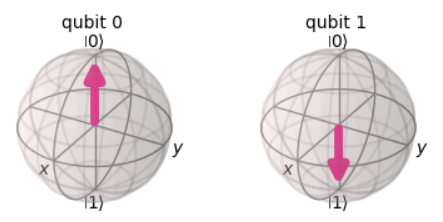

D) 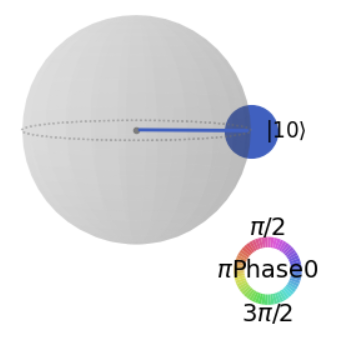


***정답:***
<Details>
<br/>
B) `H(0)`은 중첩 상태를 만들고, `X(1)`은 두 번째 큐비트를 `|1⟩` 상태로 보냅니다.
</Details>
